# Gradient Descent

## Theorem: The Gradient is the Direction of Maximal Increase
  
If $f : \mathbb{R}^n \to \mathbb{R}$ is differentiable at $x$, then:

1. For every unit vector $u$,
   $$
   D_u f(x) = \nabla f(x) \cdot u.
   $$
   where $D_u f$ denotes the derivative of $f$ in the direction of $u$.

2. Among all unit vectors $u$, the quantity $D_u f(x)$ is maximized when  
   $$
   u = \frac{\nabla f(x)}{\|\nabla f(x)\|} \quad (\nabla f(x) \neq 0),
   $$  
   and the maximal value is  
   $$
   \max_{\|u\| = 1} D_u f(x) = \|\nabla f(x)\|.
   $$

3. Among all unit vectors $u$, the quantity $D_u f(x)$ is minimized when  
   $$
   u = -\frac{\nabla f(x)}{\|\nabla f(x)\|} \quad (\nabla f(x) \neq 0),
   $$  
   and the minimal value is  
   $$
   \min_{\|u\| = 1} D_u f(x) = -\|\nabla f(x)\|.
   $$



**Proof 1:**. Directional derivative as inner product

For a unit vector $u \in \mathbb{R}^n$, the directional derivative of $f$ at $x$ in the direction $u$ is defined as:

$$
D_u f(x) = \lim_{h \to 0} \frac{f(x + h u) - f(x)}{h}.
$$

Since $f$ is differentiable at $x$, we have the first-order expansion:

$$
f(x + h u) = f(x) + h \, \nabla f(x) \cdot u + o(h).
$$

Thus:

$$
\frac{f(x + h u) - f(x)}{h}
= \nabla f(x) \cdot u + \frac{o(h)}{h}.
$$

Taking $h \to 0$ gives:

$$
D_u f(x) = \nabla f(x) \cdot u.
$$

**Proof 2,3:** 

By applying the Cauchy–Schwarz inequality to the equality in (1.), for any unit vector $u$, we have

$$
|D_u f(x)|= |\nabla f(x)\cdot u| \le \|\nabla f(x)\| \, \|u\| = \|\nabla f(x)\|.
$$

Thus,

$$
-\|\nabla f(x)\| \le D_u f(x) \le \|\nabla f(x)\|, \quad \forall u : \|u\| = 1.
$$
In addition equality in Cauchy–Schwarz holds if and only if $v = \alpha \nabla f(x)$, for some $\alpha\in \mathbb{R}$. Since $\|v\|=1$, we get $|\alpha|=\frac{1}{\|\nabla f(x)\|}$ and consequently $\alpha=\pm \frac{1}{\|\nabla f(x)\|}$. So, maximum and minimum are achieved only at $v_{1,2}= \pm \frac{\nabla f(x)}{\|\nabla f(x)\|}$. By simple evaluation we get the result
$$
D_{v_{1,2}} f(x)=\nabla f(x)^{T}\cdot \frac{\pm\nabla f(x)}{\|\nabla f(x)\|}=\pm\frac{\|\nabla f(x)\|^2}{\|\nabla f(x)\|}= \pm\|\nabla f(x)\|.
$$

## Definition: Gradient Descent 
We want to minimize a loss function

$$
L(\theta|\{x_i,y_i\}_{i=1}^{N}) = \frac{1}{N} \sum_{i=1}^N \ell(\theta| x_i, y_i).
$$


### 1. Full-Batch Gradient Descent 

$$
\theta_{t+1} = \theta_t - \eta_t \, \nabla_\theta L(\theta_t).
$$

### 2. Stochastic Gradient Descent (single sample)

At iteration $t$, pick a random index $i_t \sim \{1,\dots,N\}$:

$$
\theta_{t+1}
= \theta_t - \eta_t \, \nabla_\theta \ell(\theta_t; x_{i_t}, y_{i_t}).
$$

###  3. Mini-Batch Stochastic Gradient Descent

Take a random set of index $B_t\subset\{1,2,\dots,N\}$ of size $m$:

$$
\theta_{t+1}
= \theta_t
- \eta_t \, \frac{1}{|B_t|}
  \sum_{i \in B_t}
  \nabla_\theta \ell(\theta_t; x_i, y_i).
$$

### Property: Gradient Variance decreases with batch size

Let's denote by $\mathcal{B}_i$ the $i$-th batch which is uniformly randomly selected and each sample $(X,Y)=(x,y)$ is uniformly randomly selected in the batch. Let's denote $\sigma^2_{S}$ and $\sigma^2_{MB}$ the variances of the SGD and mini-batch GD algorithms respectively  

$$
\begin{align*}
\sigma^2_{S}&=\mathbb{V}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right],\\
\sigma^2_{MB}&=\mathbb{V}\left[\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right].
\end{align*}
$$
Then
$$
\begin{align*}
\sigma^2_{S}\ge \sigma^2_{MB}.
\end{align*}
$$

**Proof:** Consither the random variable
$$
\begin{align*}
Z(i) = \mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right],
\end{align*}
$$
where $\ell$ is the loss funciton and $\theta$ are the learnable model parameters.

From the Law of total expectation, we have

$$
\begin{align*}
\mathbb{E}\left[\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right]=\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right],
\end{align*}
$$

then we have that the variance of minibatch-SGD is 
$$
\begin{align*}
\sigma^2_{MB}&=\mathbb{E}[(Z-\mathbb{E}[Z])^2]=\mathbb{E}[Z^2]-\mathbb{E}[Z]^2,\\
&=\mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2
\end{align*}
$$

If we take bathch_size = 1, then $X,Y\in\mathcal{B}_i$ is deterministic and  we get that the SGD variance is 

$$
\begin{align*}
\sigma^2_{S}&=\mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2,\\
&=\mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]-\mathbb{E}\left[\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right]^2
\end{align*}
$$

Then, the variance reduction is

$$
\begin{align*}
\sigma^2_{S}-\sigma_{MB}^2&=\mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\left(\mathbb{E}\left[\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right| X,Y \in \mathcal{B}_i\right]\right)^2\right],\\
&\geq \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\mathbb{E}\left[\left(\left.\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right| X,Y \in \mathcal{B}_i\right]\right],\\
&= \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right]- \mathbb{E}\left[\left(\frac{\partial}{\partial \theta}  \ell (\theta|X,Y)\right)^2\right],\\
&=0.
\end{align*}
$$

Then we have proved that minibatch GD never increases the variance of SGD: $\sigma^2_{S}\geq \sigma^2_{MB}$.

## Definition: SGD with Momentum

We consider a loss function $L(\theta)$ and its (stochastic) gradient at step $t$,
$$
g_t = \nabla_\theta L(\theta_t),
$$
where the gradient acts like a force that pushes the velocity in the descent direction.

Momentum introduces a **velocity** vector $v_t$ that accumulates past forces, giving the update a physics-like interpretation:
$$
\begin{align*}
v_0 &= 0,\\[4pt]
v_{t+1} &= \mu v_t + g_t,\\[4pt]
\theta_{t+1} &= \theta_t - \eta\, v_{t+1},
\end{align*}
$$

where $\eta > 0$ is the learning rate and $\mu \in [0,1)$ controls how much past velocity is preserved.

### Property: Old gradients are exponentially forgotten (their weight decays like $\alpha^k$).
$$
v_{n+1} = \sum_{i=0}^n \mu^{n-i} g_{i}
$$
Intuitively, momentum lets the optimizer “build up speed” in directions where many gradients agree, which reduces zig-zagging and speeds up progress through flat regions.

**Proof:** Let's prove it by induction on $n$. 

For $n=0$, we have $v_{1}=\mu v_0+g_0=g_0$ on the left side, and on the right side we have 
$$\sum_{i=0}^0\mu^{0-i}g_{i}=\mu^{0-0}g_0=g_0,$$
so the equality is true for $n=0$.

Let's prove the induction step, assume the equation is true for $n-1$, then we have

$$
\begin{align*}
v_{n+1} &= \mu v_{n} + g_{n},\\
&= \mu\sum_{i=0}^{n-1} \mu^{n-1-i} g_i + g_{n},\\
&= \sum_{i=0}^{n-1} \mu^{n-i} g_i+ 
u^0g_{n},\\
&= \sum_{i=0}^{n} \mu^{n-i} g_i.
\end{align*}
$$
so it is also true for $n$ and the inducion is completed.

## Definition: SGD with damped momentum
Dampening scales down the new gradient in the momentum update, making the step less aggressive. In practice, dampening is rarely needed in modern deep learning because the learning rate and momentum hyperparameters already provide equivalent control. It remains mostly for historical completeness rather than mathematical necessity.

$$
v_{t+1} = \mu v_t + (1 - \delta) g_t,
\qquad v_0 = 0,
$$

## Definition: SGD with Nesterov Momentum

Nesterov momentum improves classical momentum by *predicting* where momentum is about to move the parameters and then computing the gradient at that “future” position. This anticipatory step makes the correction earlier and more accurate, which reduces overshooting and typically leads to faster convergence.

We first compute the look-ahead position (before applying the new gradient):
$$
\hat\theta_t = \theta_t - \eta \mu v_t.
$$

We then compute the gradient at this look-ahead point:
$$
\hat{g}_t = \nabla_\theta L(\hat\theta_t).
$$

Finally, we update the velocity and the parameters just like in classical momentum:
$$
\begin{align*}
v_{t+1} &= \mu v_t + \hat{g}_t,\\
\theta_{t+1} &= \theta_t - \eta\, v_{t+1}.
\end{align*}
$$


## PyTorch’s Nesterov-Style Algorithm

The update implemented in PyTorch when `nesterov=True` is **not** the classical
Nesterov Accelerated Gradient (NAG). It is a **Nesterov-style momentum
heuristic**: inspired by the idea of looking ahead, but not mathematically
derived from the original algorithm.

PyTorch does **not** compute the displaced gradient $\hat g_t$. Instead, it uses
the usual gradient $g_t = \nabla L(\theta_t)$ and applies the heuristic update:
$$
\begin{align*}
d_t &= g_t + \mu v_{t+1},\\
\theta_{t+1} &= \theta_t - \eta\, d_t.
\end{align*}
$$

This rule is **not** an approximation of true Nesterov and is **not**
mathematically equivalent. It is an engineering shortcut (Sutskever et al.,
2013) that imitates the early-correction behavior of Nesterov without having
to temporarily move the parameters to a look-ahead position and restore them,
which would require copying all model weights every iteration.

Deep-learning libraries (PyTorch, TensorFlow, JAX, Keras) use this variant
because it is cheap, simple, and empirically improves stability compared to
classical momentum, even though it is not the original NAG method.

## Definition Weight decay (L2 regularization)

Weight decay (L2 regularization) helps prevent overfitting by discouraging very large weights. Large parameters make the model overly sensitive to small input changes, producing unstable predictions. Penalizing weight magnitude keeps the model smoother and more stable. This is achieved by adding a small L2 penalty to the loss:
$$
L_{\text{reg}}(\theta)=L(\theta)+\frac{\lambda}{2}\|\theta\|^2.
$$
where $\lambda \ge 0$ is the weight decay coefficient.

### Property
$$
\nabla_\theta L_{\text{reg}}(\theta)
= \nabla_\theta L(\theta) + \lambda\,\theta.
$$

**Proof:**
Since gradient is a linear operator we have
$$
\begin{align*}
\nabla_\theta L_{\text{reg}}(\theta)
&= \nabla_\theta \left(L(\theta) +\frac{\lambda}{2}\|\theta\|^2\right),\\
&= \nabla_\theta \left(L(\theta)\right) + \frac{\lambda}{2}\nabla_\theta \left(\|\theta\|^2\right),\\
&= \nabla_\theta L(\theta) +\frac{\lambda}{2}\left(2\theta\right),\\
&= \nabla_\theta L(\theta) + \lambda\theta.
\end{align*}
$$

## Code: Gradient Descent

In [1]:
import torch
from torch import Tensor, nn
from matplotlib import pyplot as plt
import imageio.v2 as imageio
from IPython.display import Video
import numpy as np
from typing import Any
import optimizers as mynn
plt: Any


### Data

In [2]:
def f(x:Tensor) -> Tensor:
    return 1+2*x**2

N = 20
xs = (4*torch.rand(N)-2).unsqueeze(1)
ys = f(xs) + 0.5*torch.randn(N).unsqueeze(1)

x = torch.linspace(-2,2,100,requires_grad=True)
x_eval = torch.linspace(-2,2,100)
torch.manual_seed(1) # type: ignore

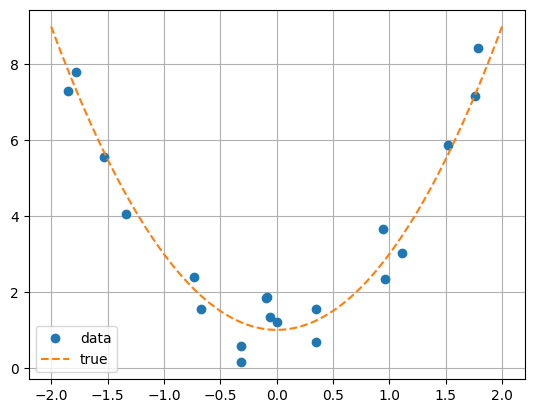

In [3]:
plt.plot(xs.detach().numpy(), ys.detach().numpy(), 'o',label='data')
plt.plot(x.detach().numpy(), f(x).detach().numpy(), '--',label='true')
plt.legend()
plt.grid()
plt.show()

### Training loop

In [4]:
def param_space(a:Tensor,modela:Tensor,x:Tensor,y:Tensor)-> np.ndarray:
    model_a: np.ndarray = modela.detach().numpy() 
    loss_a: Tensor = (1+a*x**2-y*torch.ones_like(a))**2
    loss_modela: np.ndarray = ((1+modela*x**2-y)**2).detach().numpy()
    fig, ax = plt.subplots()
    
    ax.scatter(model_a,loss_modela, color='red')
    ax.plot(a.detach().numpy(),loss_a.detach().numpy() )
    ax.set_ylim(0,10)
    ax.grid()
    fig.canvas.draw()
    frame_image = np.array(fig.canvas.buffer_rgba())[..., :3]  # (H,W,3)
    plt.ylim(0, 10)
    plt.close(fig)
    return frame_image

def train(
    model: nn.Module,
    opt: torch.optim.Optimizer,
    loss_fn: nn.Module,
    data: tuple[Tensor, Tensor],
    epochs: int = 20,
    batch_size: int = 1,
    record_param: str = ""
):
    xs, ys = data
    N = xs.shape[0]
    model.train()
    losses: list[float] = []
    frames:list[np.ndarray]=[]
    for epoch in range(epochs):
        perm = torch.randperm(N)  # shuffle for stochasticity each epoch
        for i in range(0, N, batch_size):
            batch_idx = perm[i:i + batch_size]
            x = xs[batch_idx]
            y = ys[batch_idx]

            opt.zero_grad()
            pred = model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            if record_param!="":
                a = torch.linspace(-4, 4, 100, requires_grad=True)
                frame_image=param_space(a,model.a,xs[i],ys[i]) # type: ignore
                frames.append(frame_image)
            opt.step()
        losses.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
    if record_param!="":
        imageio.mimsave(record_param+".mp4", frames, fps=20)  # type: ignore

        Video(record_param+".mp4", embed=True, html_attributes="controls autoplay loop")
            
    return losses

def compare_losses(loss,nn_loss,title):
    plt.plot(nn_loss,linestyle="-",label="nn_loss")
    plt.plot(loss,linestyle="--",label="loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

## Parameters

In [5]:
lr = 0.0005
momentum = 0.9
dampening = 0.0
weight_decay= 0.0005
nesterov = False


class Model(nn.Module):
    def __init__(self):
        super().__init__() # type: ignore
        self.a = nn.Parameter(-2*torch.ones(1))

    def forward(self, x:Tensor) -> Tensor:
        return 1 + self.a * x**2
record_name = ["full_batch_gd","sgd","mini_batch_gd"]   


loss_fn = nn.MSELoss()  

### 1. Full-Batch Gradient Descent

#### torch

In [6]:
model = Model()
opt = torch.optim.SGD(model.parameters(),
                      lr=lr,
                      momentum=momentum,
                      dampening=dampening,
                      weight_decay=weight_decay,
                      nesterov=nesterov)
nn_loss = train(model,opt,loss_fn,(xs,ys),epochs=150,batch_size=N,record_param=record_name[0])

Epoch 1/150, Loss: 48.4663
Epoch 2/150, Loss: 48.1818
Epoch 3/150, Loss: 47.6442
Epoch 4/150, Loss: 46.8847
Epoch 5/150, Loss: 45.9332
Epoch 6/150, Loss: 44.8181
Epoch 7/150, Loss: 43.5663
Epoch 8/150, Loss: 42.2026
Epoch 9/150, Loss: 40.7501
Epoch 10/150, Loss: 39.2296
Epoch 11/150, Loss: 37.6601
Epoch 12/150, Loss: 36.0587
Epoch 13/150, Loss: 34.4404
Epoch 14/150, Loss: 32.8186
Epoch 15/150, Loss: 31.2050
Epoch 16/150, Loss: 29.6097
Epoch 17/150, Loss: 28.0412
Epoch 18/150, Loss: 26.5067
Epoch 19/150, Loss: 25.0124
Epoch 20/150, Loss: 23.5631
Epoch 21/150, Loss: 22.1628
Epoch 22/150, Loss: 20.8143
Epoch 23/150, Loss: 19.5198
Epoch 24/150, Loss: 18.2810
Epoch 25/150, Loss: 17.0985
Epoch 26/150, Loss: 15.9728
Epoch 27/150, Loss: 14.9035
Epoch 28/150, Loss: 13.8903
Epoch 29/150, Loss: 12.9321
Epoch 30/150, Loss: 12.0278
Epoch 31/150, Loss: 11.1761
Epoch 32/150, Loss: 10.3751
Epoch 33/150, Loss: 9.6233
Epoch 34/150, Loss: 8.9188
Epoch 35/150, Loss: 8.2596
Epoch 36/150, Loss: 7.6438
Epoch

### custom

Epoch 1/150, Loss: 48.4663
Epoch 2/150, Loss: 48.1818
Epoch 3/150, Loss: 47.6442
Epoch 4/150, Loss: 46.8847
Epoch 5/150, Loss: 45.9332
Epoch 6/150, Loss: 44.8181
Epoch 7/150, Loss: 43.5663
Epoch 8/150, Loss: 42.2026
Epoch 9/150, Loss: 40.7501
Epoch 10/150, Loss: 39.2296
Epoch 11/150, Loss: 37.6601
Epoch 12/150, Loss: 36.0587
Epoch 13/150, Loss: 34.4404
Epoch 14/150, Loss: 32.8186
Epoch 15/150, Loss: 31.2050
Epoch 16/150, Loss: 29.6097
Epoch 17/150, Loss: 28.0412
Epoch 18/150, Loss: 26.5067
Epoch 19/150, Loss: 25.0124
Epoch 20/150, Loss: 23.5631
Epoch 21/150, Loss: 22.1628
Epoch 22/150, Loss: 20.8143
Epoch 23/150, Loss: 19.5198
Epoch 24/150, Loss: 18.2810
Epoch 25/150, Loss: 17.0985
Epoch 26/150, Loss: 15.9728
Epoch 27/150, Loss: 14.9035
Epoch 28/150, Loss: 13.8903
Epoch 29/150, Loss: 12.9321
Epoch 30/150, Loss: 12.0278
Epoch 31/150, Loss: 11.1761
Epoch 32/150, Loss: 10.3751
Epoch 33/150, Loss: 9.6233
Epoch 34/150, Loss: 8.9188
Epoch 35/150, Loss: 8.2596
Epoch 36/150, Loss: 7.6438
Epoch

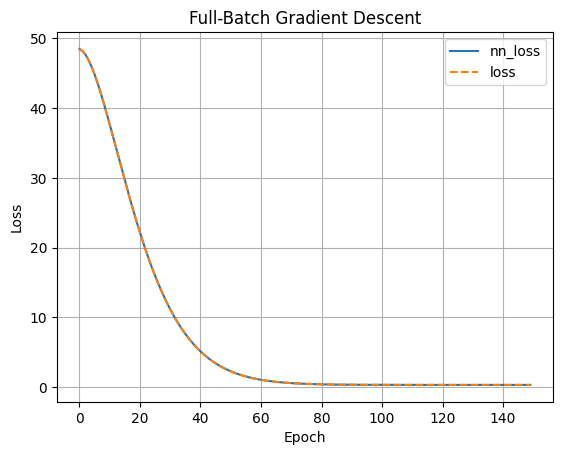

In [7]:
model = Model()
opt = mynn.SGD(model.parameters(),
          lr=lr,
          momentum=momentum,
          dampening=dampening,
          weight_decay=weight_decay,
          nesterov=nesterov)
loss = train(model,opt,loss_fn,(xs,ys),epochs=150,batch_size=N)
compare_losses(loss, nn_loss,"Full-Batch Gradient Descent")

# Evaluation

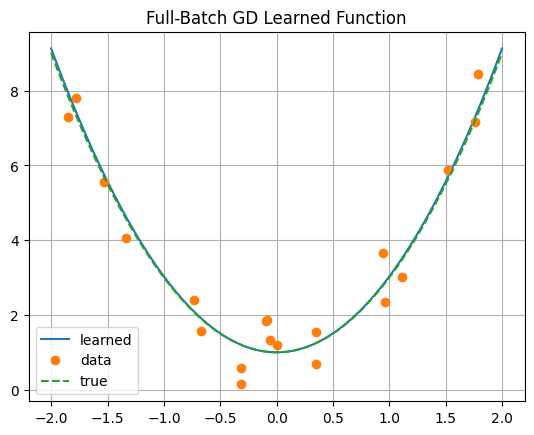

In [8]:
plt.plot(x_eval,model(x_eval[:,None]).squeeze().detach().numpy(), '-',label='learned')
plt.plot(xs.detach().numpy(), ys.detach().numpy(), 'o',label='data')
plt.plot(x_eval,f(x_eval), '--',label='true')
plt.legend()
plt.title("Full-Batch GD Learned Function")
plt.grid()
plt.show()

### 2. Stochastic Gradient Descent

#### torch

In [9]:
torch.manual_seed(0) # type: ignore
model = Model()
opt = torch.optim.SGD(model.parameters(),
                      lr=lr,
                      momentum=momentum,
                      dampening=dampening,
                      weight_decay=weight_decay,
                      nesterov=nesterov)

nn_loss = train(model,opt,loss_fn,(xs,ys),epochs=50,batch_size=1,record_param=record_name[1])

Epoch 1/50, Loss: 11.8299
Epoch 2/50, Loss: 21.1031
Epoch 3/50, Loss: 1.7149
Epoch 4/50, Loss: 0.0042
Epoch 5/50, Loss: 1.0755
Epoch 6/50, Loss: 0.8818
Epoch 7/50, Loss: 0.5449
Epoch 8/50, Loss: 0.1092
Epoch 9/50, Loss: 0.4157
Epoch 10/50, Loss: 0.2482
Epoch 11/50, Loss: 0.1093
Epoch 12/50, Loss: 0.0418
Epoch 13/50, Loss: 0.3209
Epoch 14/50, Loss: 0.7126
Epoch 15/50, Loss: 0.0255
Epoch 16/50, Loss: 0.0078
Epoch 17/50, Loss: 0.0517
Epoch 18/50, Loss: 0.0851
Epoch 19/50, Loss: 0.1190
Epoch 20/50, Loss: 0.3919
Epoch 21/50, Loss: 0.1405
Epoch 22/50, Loss: 0.0980
Epoch 23/50, Loss: 0.1017
Epoch 24/50, Loss: 0.3208
Epoch 25/50, Loss: 0.2438
Epoch 26/50, Loss: 0.7458
Epoch 27/50, Loss: 0.8854
Epoch 28/50, Loss: 0.7117
Epoch 29/50, Loss: 0.3057
Epoch 30/50, Loss: 0.2980
Epoch 31/50, Loss: 0.0722
Epoch 32/50, Loss: 0.1251
Epoch 33/50, Loss: 0.7127
Epoch 34/50, Loss: 0.3368
Epoch 35/50, Loss: 0.9357
Epoch 36/50, Loss: 0.0845
Epoch 37/50, Loss: 0.0458
Epoch 38/50, Loss: 0.2544
Epoch 39/50, Loss: 

#### custom

In [11]:
torch.manual_seed(0) # type: ignore
model = Model()
opt = mynn.SGD(model.parameters(),
          lr=lr,
          momentum=momentum,
          dampening=dampening,
          weight_decay=weight_decay,
          nesterov=nesterov)

loss = train(model,opt,loss_fn,(xs,ys),epochs=50,batch_size=1)

Epoch 1/50, Loss: 11.8299
Epoch 2/50, Loss: 21.1031
Epoch 3/50, Loss: 1.7149
Epoch 4/50, Loss: 0.0042
Epoch 5/50, Loss: 1.0755
Epoch 6/50, Loss: 0.8818
Epoch 7/50, Loss: 0.5449
Epoch 8/50, Loss: 0.1092
Epoch 9/50, Loss: 0.4157
Epoch 10/50, Loss: 0.2482
Epoch 11/50, Loss: 0.1093
Epoch 12/50, Loss: 0.0418
Epoch 13/50, Loss: 0.3209
Epoch 14/50, Loss: 0.7126
Epoch 15/50, Loss: 0.0255
Epoch 16/50, Loss: 0.0078
Epoch 17/50, Loss: 0.0517
Epoch 18/50, Loss: 0.0851
Epoch 19/50, Loss: 0.1190
Epoch 20/50, Loss: 0.3919
Epoch 21/50, Loss: 0.1405
Epoch 22/50, Loss: 0.0980
Epoch 23/50, Loss: 0.1017
Epoch 24/50, Loss: 0.3208
Epoch 25/50, Loss: 0.2438
Epoch 26/50, Loss: 0.7458
Epoch 27/50, Loss: 0.8854
Epoch 28/50, Loss: 0.7117
Epoch 29/50, Loss: 0.3057
Epoch 30/50, Loss: 0.2980
Epoch 31/50, Loss: 0.0722
Epoch 32/50, Loss: 0.1251
Epoch 33/50, Loss: 0.7127
Epoch 34/50, Loss: 0.3368
Epoch 35/50, Loss: 0.9357
Epoch 36/50, Loss: 0.0845
Epoch 37/50, Loss: 0.0458
Epoch 38/50, Loss: 0.2544
Epoch 39/50, Loss: 

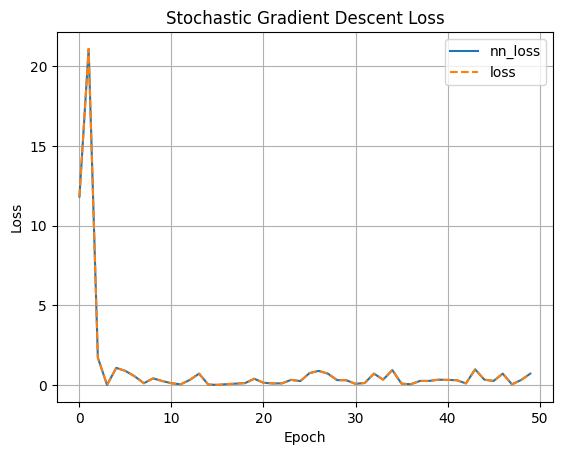

In [12]:
compare_losses(loss, nn_loss,"Stochastic Gradient Descent Loss")

# Evaluation

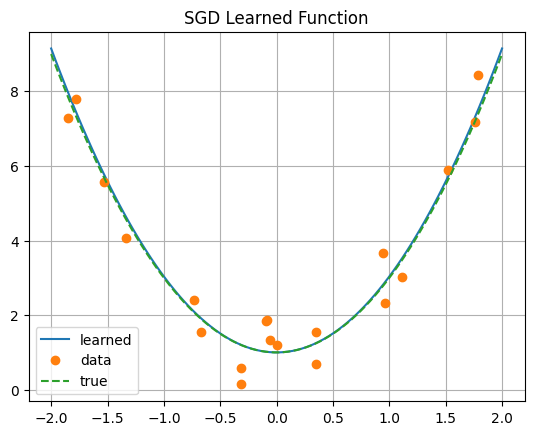

In [13]:
plt.plot(x_eval,model(x_eval[:,None]).squeeze().detach().numpy(), '-',label='learned')
plt.plot(xs.detach().numpy(), ys.detach().numpy(), 'o',label='data')
plt.plot(x_eval,f(x_eval), '--',label='true')
plt.title("SGD Learned Function")
plt.legend()
plt.grid()
plt.show()

### 3. Mini-Batch Gradient Descent

#### torch

In [ ]:
torch.manual_seed(0) # type: ignore
model = Model()
opt = torch.optim.SGD(model.parameters(),
                      lr=lr,
                      momentum=momentum,
                      dampening=dampening,
                      weight_decay=weight_decay,
                      nesterov=nesterov)

nn_loss = train(model,opt,loss_fn,(xs,ys),epochs=20,batch_size=4,record_param=record_name[2])

Epoch 1/20, Loss: 86.8408
Epoch 2/20, Loss: 90.8565
Epoch 3/20, Loss: 35.9725
Epoch 4/20, Loss: 21.3733
Epoch 5/20, Loss: 18.3696
Epoch 6/20, Loss: 32.6777
Epoch 7/20, Loss: 7.5530
Epoch 8/20, Loss: 0.5119
Epoch 9/20, Loss: 8.7583
Epoch 10/20, Loss: 0.5687
Epoch 11/20, Loss: 1.2586
Epoch 12/20, Loss: 0.5911
Epoch 13/20, Loss: 0.7675
Epoch 14/20, Loss: 1.2660
Epoch 15/20, Loss: 0.1354
Epoch 16/20, Loss: 0.2554
Epoch 17/20, Loss: 0.1461
Epoch 18/20, Loss: 0.5530
Epoch 19/20, Loss: 0.1766
Epoch 20/20, Loss: 0.1230


#### custom

In [16]:
torch.manual_seed(0) # type: ignore
model = Model()
opt = mynn.SGD(model.parameters(),
          lr=lr,
          momentum=momentum,
          dampening=dampening,
          weight_decay=weight_decay,
          nesterov=nesterov)

loss = train(model,opt,loss_fn,(xs,ys),epochs=20,batch_size=4)

Epoch 1/20, Loss: 86.8408
Epoch 2/20, Loss: 90.8565
Epoch 3/20, Loss: 35.9725
Epoch 4/20, Loss: 21.3733
Epoch 5/20, Loss: 18.3696
Epoch 6/20, Loss: 32.6777
Epoch 7/20, Loss: 7.5530
Epoch 8/20, Loss: 0.5119
Epoch 9/20, Loss: 8.7583
Epoch 10/20, Loss: 0.5687
Epoch 11/20, Loss: 1.2586
Epoch 12/20, Loss: 0.5911
Epoch 13/20, Loss: 0.7675
Epoch 14/20, Loss: 1.2660
Epoch 15/20, Loss: 0.1354
Epoch 16/20, Loss: 0.2554
Epoch 17/20, Loss: 0.1461
Epoch 18/20, Loss: 0.5530
Epoch 19/20, Loss: 0.1766
Epoch 20/20, Loss: 0.1230


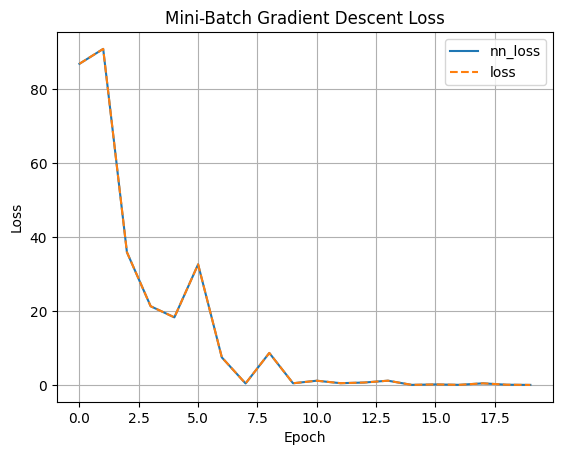

In [17]:
compare_losses(loss, nn_loss,"Mini-Batch Gradient Descent Loss")

# Evaluation

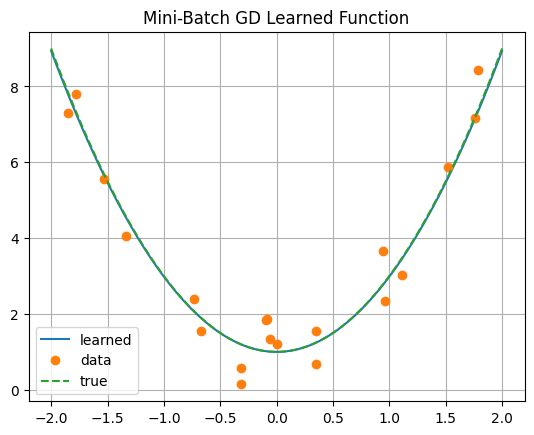

In [18]:
plt.plot(x_eval,model(x_eval[:,None]).squeeze().detach().numpy(), '-',label='learned')
plt.plot(xs.detach().numpy(), ys.detach().numpy(), 'o',label='data')
plt.plot(x_eval,f(x_eval), '--',label='true')
plt.title("Mini-Batch GD Learned Function")
plt.legend()
plt.grid()
plt.show()